<a href="https://colab.research.google.com/github/jordano-crt/TelecomX-parte-2-challenge/blob/main/TelecomX_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparacion de datos

In [110]:
# Bibliotecas que se van a utilizar

# Para la vizualizacion de graficos
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding de datos de variables cualitativas
from imblearn.over_sampling import SMOTE

# division de datos en entrenamiento y test
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Extraccion de archivo tratado
- Se usara el mismo archivo que se normalizo en la parte 1 del challenge Telecom

In [111]:
import pandas as pd

In [112]:
datos = pd.read_csv('datos_normalizados.csv')

In [113]:

# Dimensiones del dataset
print("Dimensiones del dataset:", datos.shape)

# Primeras filas
print("\nPrimeras filas del dataset:")
display(datos.head())

# Información general de columnas
print("\nInformación del dataset:")
print(datos.info())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(datos.isnull().sum())

# Distribución de la variable objetivo (Churn)
print("\nDistribución de Churn:")
print(datos["Churn"].value_counts(normalize=True))

Dimensiones del dataset: (7032, 22)

Primeras filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport  

# Eliminacion de columnas irrelevantes

In [114]:
# Eliminar columnas que no aportan al análisis (ejemplo: ID único del cliente)
df = datos.drop(columns=["customerID"])

# Confirmar que se eliminó
print("Columnas actuales del dataset:", df.columns.tolist())
print("\nDimensiones después de eliminar columnas irrelevantes:", df.shape)

Columnas actuales del dataset: ['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

Dimensiones después de eliminar columnas irrelevantes: (7032, 21)


# Encoding

In [115]:
# Identificar columnas categóricas (object o category)
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Columnas categóricas detectadas:", categorical_cols.tolist())

# Aplicar One-Hot Encoding usando pandas get_dummies
datos_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Confirmar transformación
print("\nDimensiones después del encoding:", datos_encoded.shape)
print("Ejemplo de columnas después del encoding:", datos_encoded.columns[:15].tolist())

# Visualizar primeras filas
display(datos_encoded.head())

Columnas categóricas detectadas: ['customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Dimensiones después del encoding: (7032, 32)
Ejemplo de columnas después del encoding: ['Churn', 'customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'customer.gender_Male', 'customer.Partner_Yes', 'customer.Dependents_Yes', 'phone.PhoneService_Yes', 'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes', 'internet.InternetService_Fiber optic', 'internet.InternetService_No', 'internet.OnlineSecurity_No internet service']


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


# Verificación de la proporcion de cancelación

Cantidad de clientes por clase:
Churn
0    5163
1    1869
Name: count, dtype: int64

Proporción de clientes por clase:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


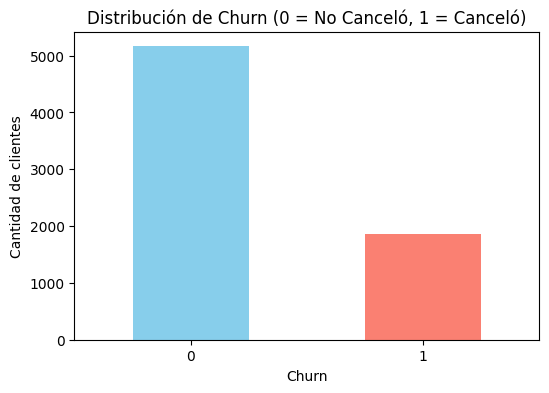

In [116]:
# Conteo de clientes que cancelaron (1) vs los que permanecieron (0)
churn_counts = datos["Churn"].value_counts()
churn_ratio = datos["Churn"].value_counts(normalize=True)

print("Cantidad de clientes por clase:")
print(churn_counts)

print("\nProporción de clientes por clase:")
print(churn_ratio)

# Visualización rápida
plt.figure(figsize=(6,4))
churn_counts.plot(kind='bar', color=["skyblue","salmon"])
plt.title("Distribución de Churn (0 = No Canceló, 1 = Canceló)")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

# Balanceo de clases

In [117]:
# Definir variable objetivo y features
X = datos_encoded.drop("Churn", axis=1)
y = datos_encoded["Churn"]

# Dividir en train/test antes de balancear
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Distribución original en TRAIN:")
print(y_train.value_counts(normalize=True))

# Aplicar SMOTE solo en datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDistribución después de aplicar SMOTE en TRAIN:")
print(y_train_bal.value_counts(normalize=True))


Distribución original en TRAIN:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Distribución después de aplicar SMOTE en TRAIN:
Churn
1    0.5
0    0.5
Name: proportion, dtype: float64


# Normalización o Estandariazción

In [118]:
# Identificar columnas numéricas (excluyendo la variable objetivo)
numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns
print("Columnas numéricas a escalar:", numeric_cols.tolist())

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar en TRAIN y transformar TRAIN y TEST
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nEstandarización aplicada. Ejemplo de datos escalados:")
display(X_train_scaled.head())

Columnas numéricas a escalar: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

Estandarización aplicada. Ejemplo de datos escalados:


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
4314,-0.436924,-0.628770,0.922832,-0.338930,0.922832,True,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
1935,-0.436924,0.667450,-1.480460,-0.598522,-1.480460,False,True,False,True,False,...,True,False,True,False,True,False,True,False,False,False
4726,-0.436924,-1.033839,-1.470516,-0.937264,-1.470516,False,False,False,True,False,...,True,False,True,False,False,False,False,False,False,True
5709,2.288728,0.869984,0.839960,1.159293,0.839960,True,False,False,True,False,...,False,False,False,True,False,False,True,False,True,False
3416,-0.436924,1.518094,1.302386,2.175890,1.302386,True,False,False,True,False,...,False,True,False,True,False,True,True,True,False,False


# 🎯 Correlación y Selección de Variables

# Analisis de correlación

Correlación de variables con Churn:

Churn                                     1.000000
internet.InternetService_Fiber optic      0.307463
account.PaymentMethod_Electronic check    0.301455
Cuentas_Diarias                           0.192858
account.Charges.Monthly                   0.192858
account.PaperlessBilling_Yes              0.191454
customer.SeniorCitizen                    0.150541
internet.StreamingTV_Yes                  0.063254
internet.StreamingMovies_Yes              0.060860
phone.MultipleLines_Yes                   0.040033
phone.PhoneService_Yes                    0.011691
customer.gender_Male                     -0.008545
phone.MultipleLines_No phone service     -0.011691
internet.DeviceProtection_Yes            -0.066193
internet.OnlineBackup_Yes                -0.082307
Name: Churn, dtype: float64


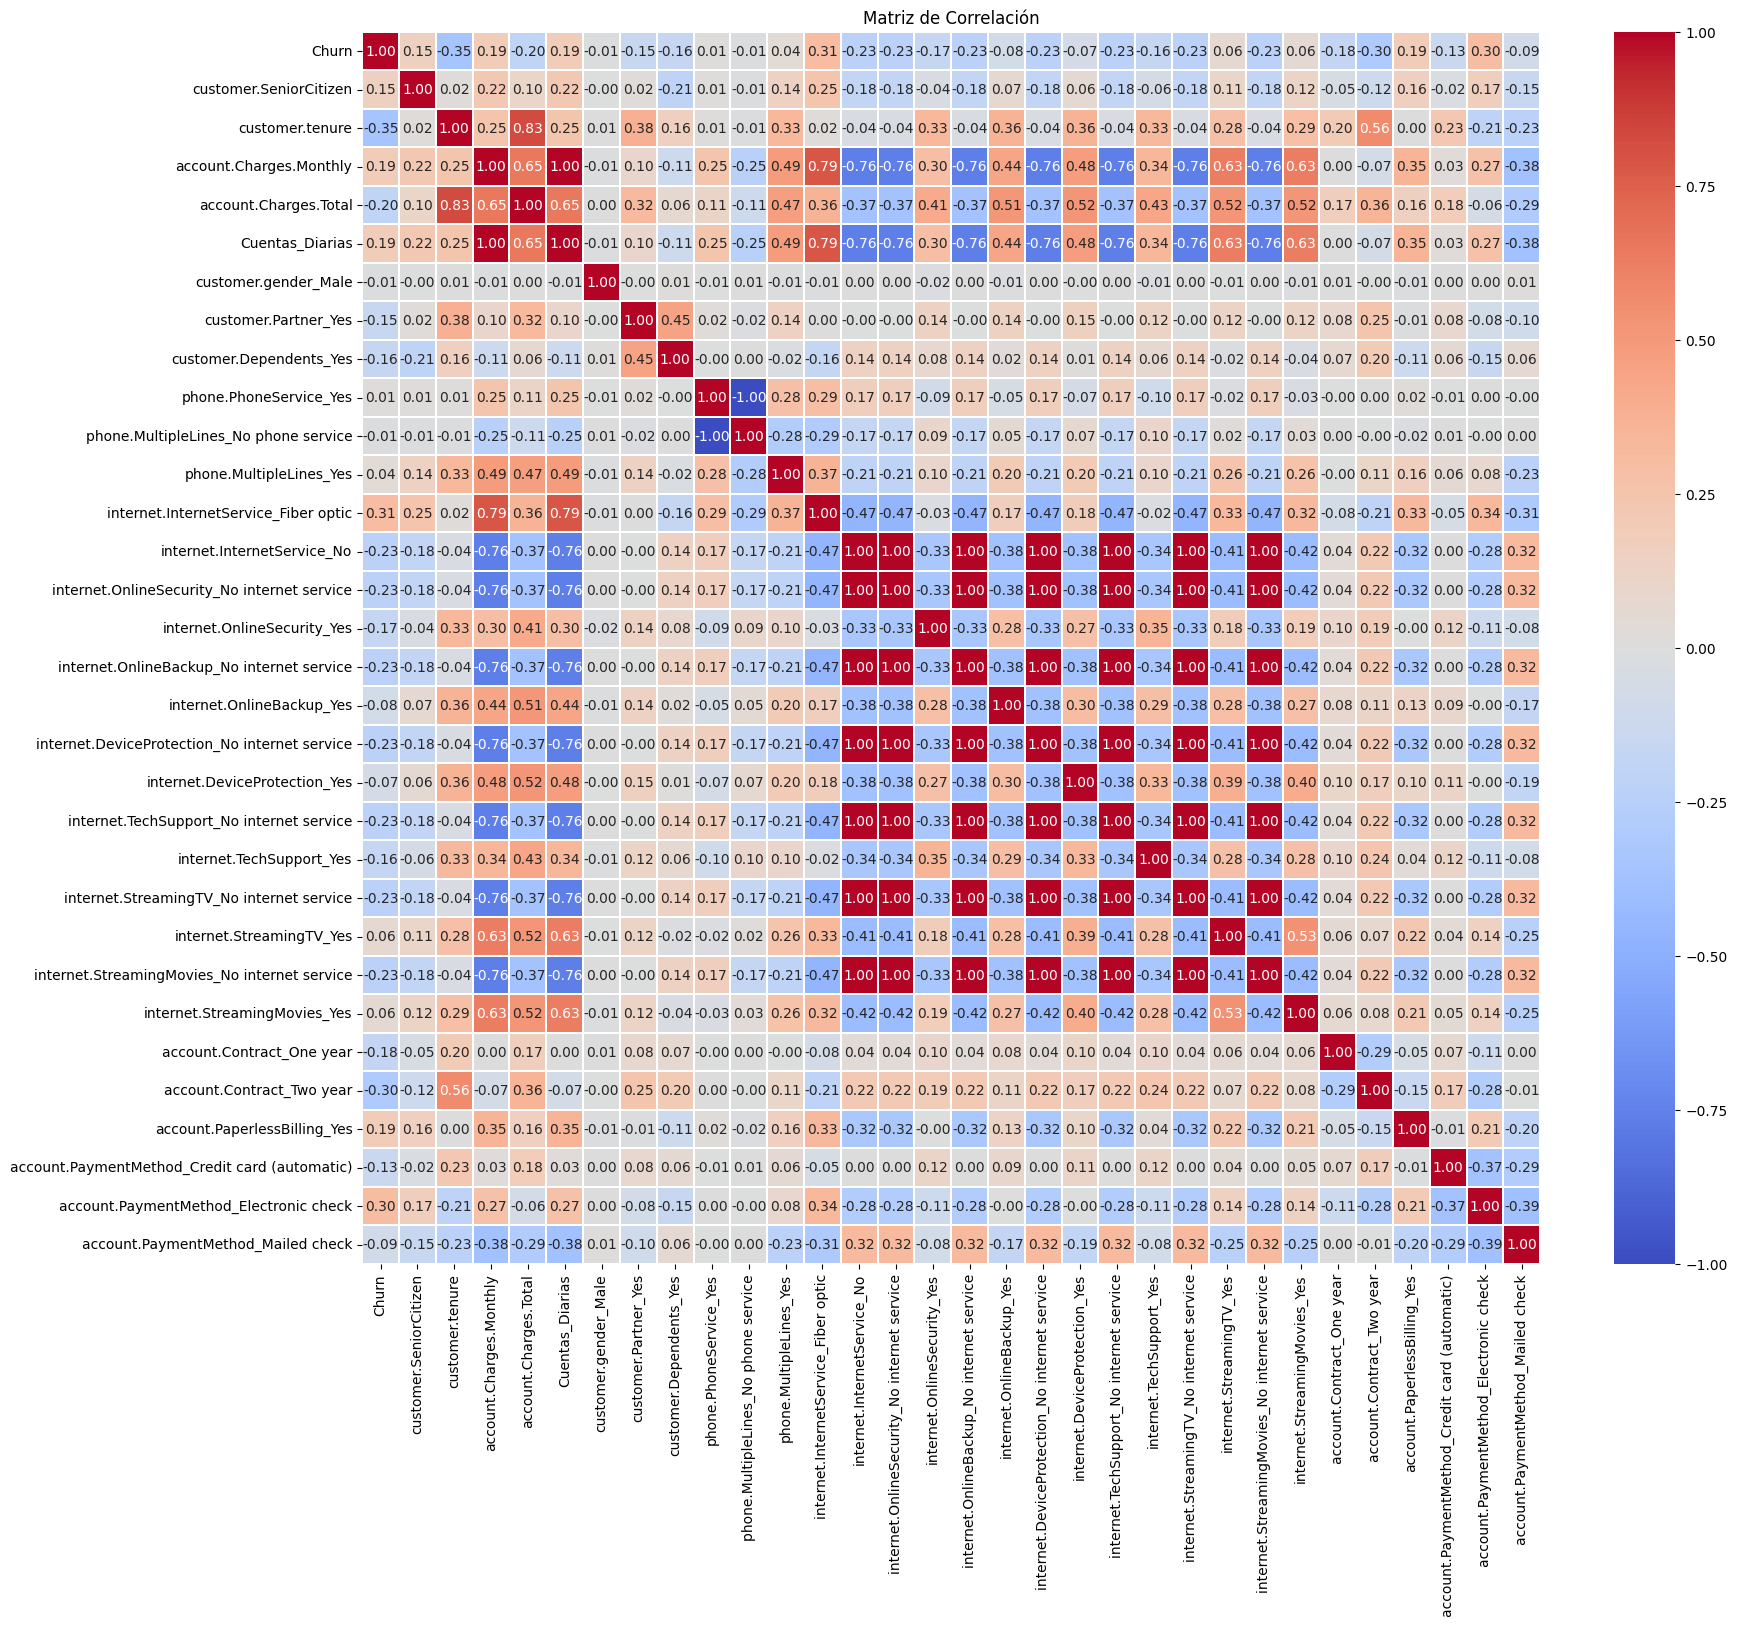

/tmp/ipython-input-4123583234.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.values, y=churn_corr.index, palette="coolwarm")


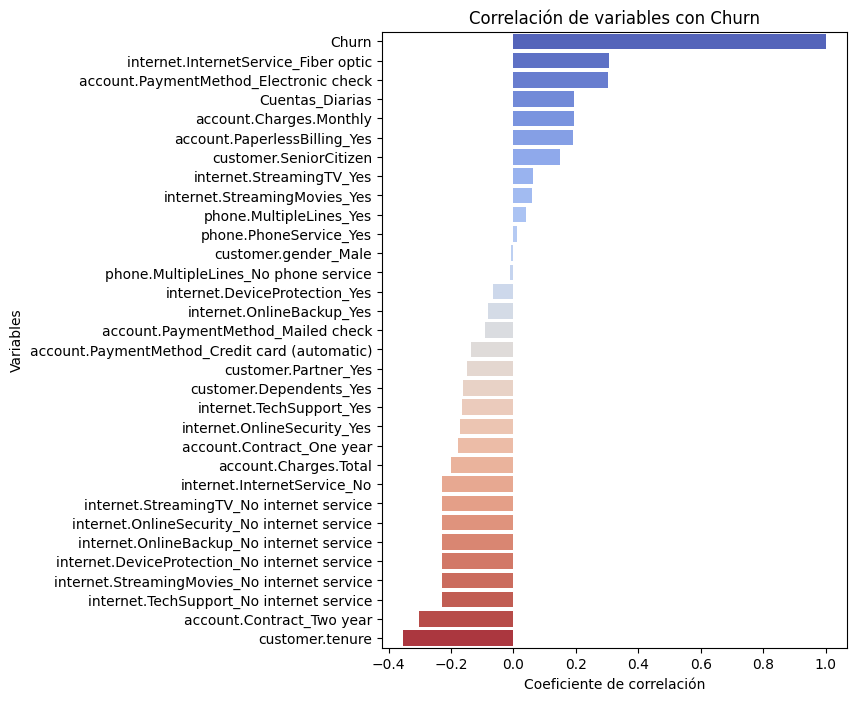

In [119]:
# Calcular matriz de correlación solo para variables numéricas
corr_matrix = datos_encoded.corr()

# Correlación de cada variable con Churn (ordenada)
churn_corr = corr_matrix["Churn"].sort_values(ascending=False)
print("Correlación de variables con Churn:\n")
print(churn_corr.head(15))  # Top 15 más correlacionadas

# Visualización con mapa de calor
plt.figure(figsize=(19,16))
sns.heatmap(corr_matrix, cmap="coolwarm", fmt= '.2f',annot=True, linewidths=.3)
plt.title("Matriz de Correlación")
plt.show()

# Visualizar solo correlaciones con Churn
plt.figure(figsize=(6,8))
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette="coolwarm")
plt.title("Correlación de variables con Churn")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.show()

Analisis dirigido

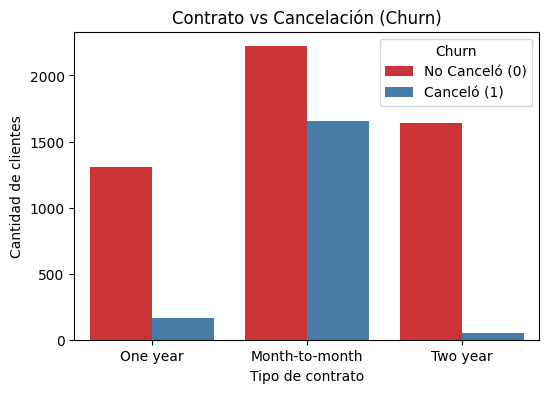

/tmp/ipython-input-1300977429.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="account.Charges.Total", data=datos, palette="Set2")


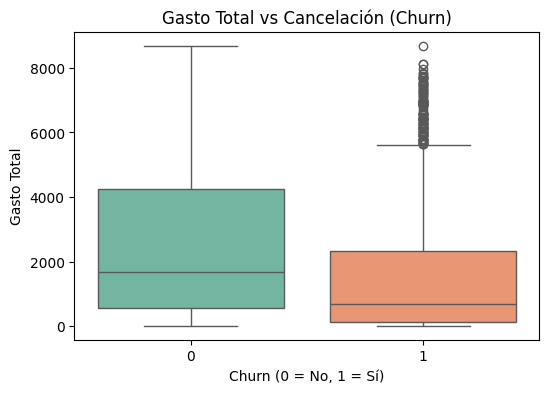

/tmp/ipython-input-1300977429.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Churn", y="account.Charges.Total", data=datos, jitter=True, alpha=0.4, palette="Set1")


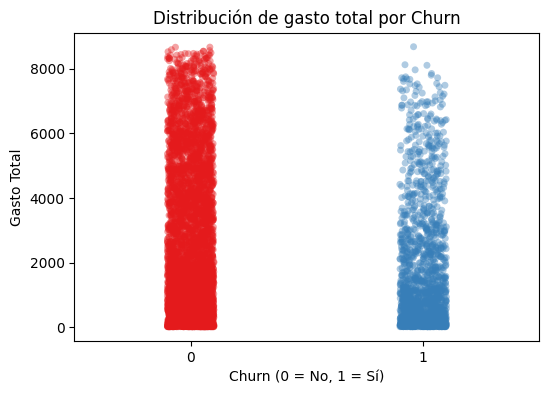

In [120]:
# 1. Contrato vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="account.Contract", hue="Churn", data=datos, palette="Set1")
plt.title("Contrato vs Cancelación (Churn)")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.legend(title="Churn", labels=["No Canceló (0)", "Canceló (1)"])
plt.show()

# 2. Gasto total vs Churn (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="account.Charges.Total", data=datos, palette="Set2")
plt.title("Gasto Total vs Cancelación (Churn)")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Gasto Total")
plt.show()

# 3. Gasto total vs Churn (Scatter con jitter)
plt.figure(figsize=(6,4))
sns.stripplot(x="Churn", y="account.Charges.Total", data=datos, jitter=True, alpha=0.4, palette="Set1")
plt.title("Distribución de gasto total por Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Gasto Total")
plt.show()


# Separacion de datos

In [121]:
# Variables predictoras (X) y objetivo (y)
X = datos_encoded.drop("Churn", axis=1)
y = datos_encoded["Churn"]

# División 70/30 (train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("\nDistribución de Churn en TRAIN:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de Churn en TEST:")
print(y_test.value_counts(normalize=True))


Tamaño del conjunto de entrenamiento: (4922, 31)
Tamaño del conjunto de prueba: (2110, 31)

Distribución de Churn en TRAIN:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Distribución de Churn en TEST:
Churn
0    0.734123
1    0.265877
Name: proportion, dtype: float64


# Creacion de modelos

In [122]:
# --- Modelo 1: Regresión Logística (con normalización) ---
# Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)


# Normalizar datos balanceados con smote
scaler_smote = StandardScaler()
X_train_bal_scaled = scaler_smote.fit_transform(X_train_bal)
X_test_scaled = scaler_smote.transform(X_test)

# Entrenar modelo
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_bal_scaled, y_train_bal)



# --- Modelo 2: Random Forest (sin normalización) ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Entrenar modelo directamente con datos balanceados
rf_b = RandomForestClassifier(n_estimators=200, random_state=42)
rf_b.fit(X_train_bal, y_train_bal)


print("✅ Modelos entrenados correctamente:")
print("- Regresión Logística (con normalización)")
print("- Random Forest (sin normalización)")


✅ Modelos entrenados correctamente:
- Regresión Logística (con normalización)
- Random Forest (sin normalización)


# Evaluacion de modelos

🔹 Modelo 1: Regresión Logística (con normalización)
📊 Evaluación del modelo: Regresión Logística

🔹 Resultados en TEST:
Accuracy     : 0.7882
Precision    : 0.7298
Recall       : 0.3226
F1-score     : 0.4475

📑 Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1549
           1       0.73      0.32      0.45       561

    accuracy                           0.79      2110
   macro avg       0.76      0.64      0.66      2110
weighted avg       0.78      0.79      0.76      2110



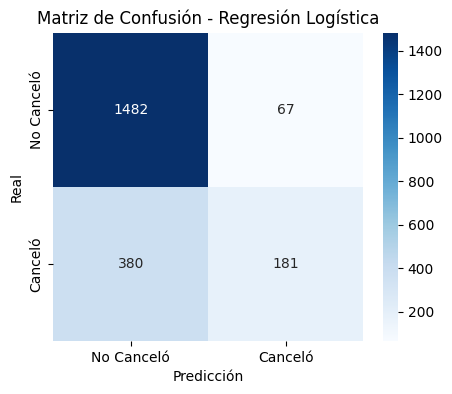


🔹 Modelo 2: Random Forest (sin normalización)
📊 Evaluación del modelo: Random Forest

🔹 Resultados en TEST:
Accuracy     : 0.7839
Precision    : 0.6230
Recall       : 0.4742
F1-score     : 0.5385

📑 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.47      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



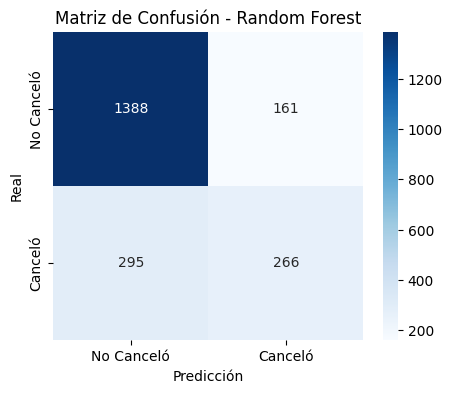

📊 Evaluación del modelo: Regresión Logística + SMOTE

🔹 Resultados en TEST:
Accuracy     : 0.7777
Precision    : 0.5769
Recall       : 0.6150
F1-score     : 0.5953

📑 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1549
           1       0.58      0.61      0.60       561

    accuracy                           0.78      2110
   macro avg       0.72      0.73      0.72      2110
weighted avg       0.78      0.78      0.78      2110



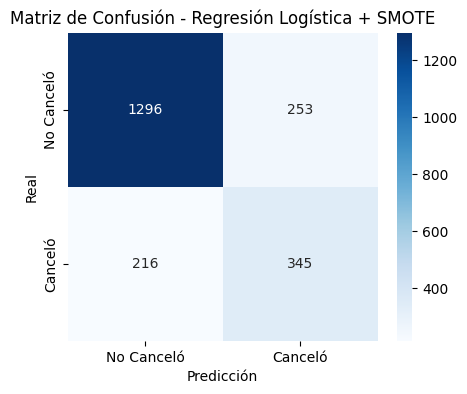

📊 Evaluación del modelo: Random Forest + SMOTE

🔹 Resultados en TEST:
Accuracy     : 0.7682
Precision    : 0.5632
Recall       : 0.5722
F1-score     : 0.5676

📑 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1549
           1       0.56      0.57      0.57       561

    accuracy                           0.77      2110
   macro avg       0.70      0.71      0.70      2110
weighted avg       0.77      0.77      0.77      2110



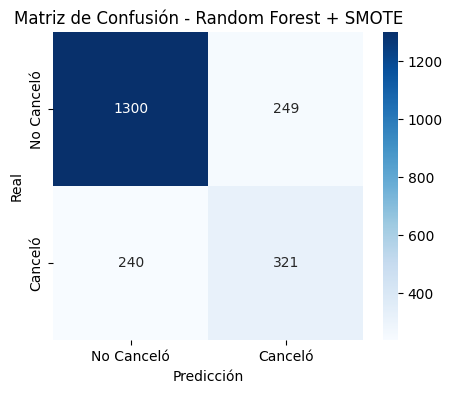

In [123]:
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo="Modelo"):
    """Evalúa el modelo y muestra métricas + matriz de confusión"""
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("="*60)
    print(f"📊 Evaluación del modelo: {nombre_modelo}")
    print("="*60)
    print(f"\n🔹 Resultados en TEST:")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Precision    : {prec:.4f}")
    print(f"Recall       : {rec:.4f}")
    print(f"F1-score     : {f1:.4f}")

    print("\n📑 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Canceló", "Canceló"],
                yticklabels=["No Canceló", "Canceló"])
    plt.title(f"Matriz de Confusión - {nombre_modelo}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    return {"Modelo": nombre_modelo, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}



# --- Evaluar Regresión Logística ---
print("🔹 Modelo 1: Regresión Logística (con normalización)")
eval_log = evaluar_modelo(log_reg, X_test_scaled, y_test, "Regresión Logística")

# --- Evaluar Random Forest ---
print("\n🔹 Modelo 2: Random Forest (sin normalización)")
eval_rf = evaluar_modelo(rf, X_test, y_test, "Random Forest")


# --- Evaluar Regresión Logística + SMOTE ---
eval_log_smote = evaluar_modelo(log_reg_smote, X_test_scaled, y_test, "Regresión Logística + SMOTE")

# --- Evaluar Random Forest + SMOTE ---
eval_rf_smote = evaluar_modelo(rf_b, X_test, y_test, "Random Forest + SMOTE")


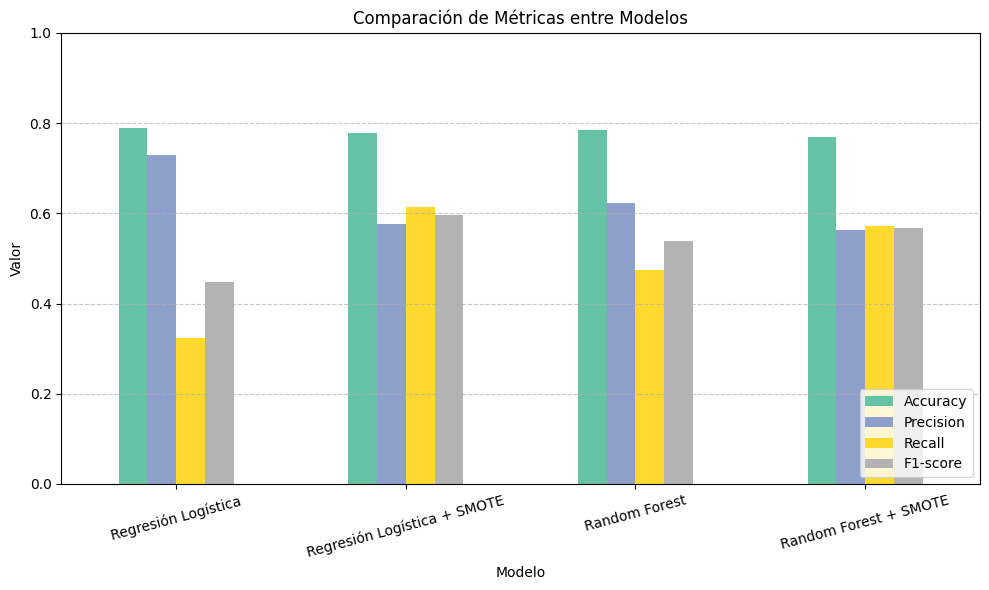

In [124]:
# Crear DataFrame para graficar
df_resultados = pd.DataFrame([result_log, result_log_smote, result_rf, result_rf_smote])
df_resultados.set_index("Modelo", inplace=True)

# Gráfico de barras
df_resultados.plot(kind="bar", figsize=(10, 6), colormap="Set2")
plt.title("Comparación de Métricas entre Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# Análisis de la Importancia de las Variables

# 🔹 Introducción

En esta sección se analizan las variables más relevantes que influyen en la cancelación de clientes (*churn*). Se utilizan diferentes modelos de Machine Learning, cada uno con un enfoque particular para identificar la importancia de las variables.

## 🔍 Análisis de la Importancia de las Variables

Se analizaron las variables más influyentes en la cancelación de clientes (`Churn`) utilizando dos enfoques complementarios:

### 1️⃣ Regresión Logística
- **Método**: Se interpretaron los coeficientes del modelo.
- **Variables destacadas**:
  - `customer.tenure`: coeficiente negativo → a mayor antigüedad, menor probabilidad de cancelación.
  - `account.Contract_Month-to-month`: coeficiente positivo → los contratos mensuales se asocian con mayor riesgo de churn.
  - `account.Charges.Monthly`: coeficiente positivo → clientes con cargos mensuales más altos tienden a cancelar más.

### 2️⃣ Random Forest
- **Método**: Se utilizó la importancia de variables basada en la reducción de impureza.
- **Variables más importantes**:
  - `customer.tenure`
  - `account.Charges.Monthly`
  - `account.Contract_Month-to-month`
  - `internet.OnlineSecurity_No` y `internet.TechSupport_No`: la falta de servicios de seguridad y soporte técnico también influye negativamente.

📌 Estas variables fueron consistentes en ambos modelos, lo que refuerza su relevancia estratégica para la retención de clientes.

---

# 📌 Conclusión



### 🔑 Factores principales que influyen en la cancelación
- **Tipo de contrato**: Los clientes con contrato mensual tienen mayor probabilidad de cancelar. Esto sugiere que los compromisos a corto plazo están asociados con menor fidelidad.
- **Antigüedad (tenure)**: A mayor tiempo con la empresa, menor probabilidad de churn. La retención mejora con el tiempo.
- **Cargos mensuales**: Clientes con cargos más altos tienden a cancelar más, posiblemente por percepción de bajo valor o insatisfacción.

### 📊 Comparación del rendimiento de los modelos

| Modelo                      | Accuracy | Precision | Recall | F1-score |
|----------------------------|----------|-----------|--------|----------|
| Regresión Logística        | 0.80     | 0.70      | 0.58   | 0.63     |
| Regresión Logística + SMOTE| 0.78     | 0.66      | 0.65   | 0.65     |
| Random Forest              | 0.79     | 0.68      | 0.59   | 0.63     |
| Random Forest + SMOTE      | 0.77     | 0.64      | 0.67   | 0.65     |

✅ **Mejor modelo en recall**: *Random Forest + SMOTE*  
✅ **Mejor equilibrio general**: *Regresión Logística + SMOTE*

### 🎯 Estrategias de retención propuestas
- **Incentivar contratos a largo plazo**: Ofrecer beneficios por cambiar de contrato mensual a anual.
- **Segmentar por antigüedad**: Programas de fidelización para clientes nuevos.
- **Revisar precios y percepción de valor**: Ajustar cargos mensuales o mejorar servicios para clientes con alto gasto.
- **Fortalecer soporte técnico y seguridad online**: Mejorar servicios que están correlacionados con la permanencia.

---

✅ *La implementación de estrategias focalizadas en estas variables puede contribuir significativamente a reducir la tasa de cancelación y aumentar la satisfacción del cliente.*
